# D214 Capstone: Quantile Regression

D214 Capstone: Quantile Regression

Data Analytics Graduate Capstone

Instructor: Dr. Daniel Smith

Student Name: Devon E. Johnson

Student ID: 011494484

Email: djo3593@wgu.edu


### Table of Contents

* [A: Research Question](#A:-Research-Question)
* [B: Data Collection](#B1:Data-Collection)
* [C: Data Extraction and Preparation](#B2:-Data-Extraction-and-Preparation)
* [D: Analysis](#D:-Analysis)
* [E: Data Summary and Implications](#E:-Data-Summary-and-Implications)
* [F: Source References](#F:-Source-References)

## A: Research Question

This project will use a regression model to analyze commercial data published on Kaggle.com containing 10,000 sales transactions across seven regions, 12 product categories, two sales channels, four levels of order priority, and date of sale to determine which factors strongly predict higher profit per transaction.

My research question is as follows: Given region of sale, product type, sale channel, order priority, and seasonality, which factors most strongly predict higher profit per transaction? As such, the null hypothesis is that none of the factors predict profit per transaction at any quantile of the profit distribution, and the alternate hypothesis is that at least one factor significantly predicts profit per transaction.

Knowing what drives profit per transaction gives a business something to act on. For instance, if the item type is identified as significant, the business might want to prioritize product categories with higher profit margins. Alternatively, if the region or season of sale is identified as more influential, the business might reallocate resources to the regions and/or seasons that generate higher returns.

## B: Data Collection

My data is derived from Kaggle.com and published by Omar Adel, a data scientist located in Cairo, Egypt. The data does not specify the name of the company from which the records are sourced, but contains 10,000 sales transactions spanning seven and a half years, with data on seven separate regions of sale, 185 countries of sale, 12 item types, two sales channels (online or offline), four order priorities (critical, high, medium, low), order date, order ID, ship date, units sold, unit price, unit cost, total revenue, total cost, and total profit. This is a publicly available dataset on Kaggle.com and is available for download to anyone who registers with a Kaggle.com account under their Terms of Use and Acceptable Use Policy (Adel, 2025).

The prime advantage of this dataset is its accessibility. Since I already had a Kaggle account, I was able to download this dataset immediately. Since the dataset was provided in a structured, clean CSV format, I was also easily able to import it using the pandas library in Jupyter notebook. Conversely, a notable disadvantage of obtaining this data from Kaggle is that I have limited insight into the data's actual origin. The summary on Kaggle did not identify the source company or industry, so it is impossible to know for sure whether the records reflect real-world transactions or if they were synthetically generated for educational purposes.

No challenges were encountered during data collection for this dataset, as the data was already well-structured and easily readable in Python.

## C: Data Extraction and Preparation

The data extraction and preparation process was conducted entirely using Python in a Jupyter Notebook hosted by Anaconda. Python's pandas library works well for data preparation and cleaning, with built-in functions for duplicate checking, variable renaming, column subsetting, and categorical variable encoding. Using Jupyter Notebook helps to make all of my code more readable by allowing one to break code into separate cells, which can be modified and rearranged according to the desired order of operations. Additionally, all the code is available in one place, with explanatory notes, and I can include Markdown cells for the written portions of my analysis. Keeping everything in one place greatly reduces user inconvenience and also aids with interpretation. Additionally, I can download the .ipynb file at any time and send it elsewhere or upload it to a code repository, such as GitHub. 

A potential disadvantage of this approach is that it requires familiarity with Python and pandas to fully understand the preparation steps. Additionally, since the extracted and prepared data is stored in an .ipynb file, recipients without compatible software would be unable to view or interact with it.

Preliminary exploratory analysis was conducted to initially assess suitability for multiple linear regression since the dependent variable is continuous. I began by conducting a standard check for duplicate data entries and also ran a check to make sure that no instances of negative profit had been recorded, as this would indicate false data since profit can never be less than zero. 

In [66]:
import pandas as pd
import numpy as np
file_path = r'C:\Users\Devon\Documents\WGU MSDA\D214\10000 Sales Records.csv'
df = pd.read_csv(file_path)
df.reset_index(inplace=True)
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   index           10000 non-null  int64  
 1   Region          10000 non-null  object 
 2   Country         10000 non-null  object 
 3   Item Type       10000 non-null  object 
 4   Sales Channel   10000 non-null  object 
 5   Order Priority  10000 non-null  object 
 6   Order Date      10000 non-null  object 
 7   Order ID        10000 non-null  int64  
 8   Ship Date       10000 non-null  object 
 9   Units Sold      10000 non-null  int64  
 10  Unit Price      10000 non-null  float64
 11  Unit Cost       10000 non-null  float64
 12  Total Revenue   10000 non-null  float64
 13  Total Cost      10000 non-null  float64
 14  Total Profit    10000 non-null  float64
dtypes: float64(5), int64(3), object(7)
memory usage: 4.4 MB


In [67]:
# Look for duplicates
print(f"Duplicate Transactions: {df.duplicated().sum()}")

Duplicate Transactions: 0


In [68]:
#Check for zero or negative profit
print((df['Total Profit'] <= 0).sum())

0


Having confirmed that there were no duplicate data entries and no records of negative profit, I investigated the number of unique values in the 'Country' and 'Region' variables, to determine which would be best-suited to keep for a regression model. Using both would undoubtedly introduce a multicollinearity issue, so it would be prudent to choose one of the two. In this light, I should choose the most generalized variable to ensure that the model doesn't become overloaded with too many dummy variables. As such, I expect that region will be the best fit, but in the interests of best practice, I will double-check before committing.

In [70]:
print(df['Region'].nunique())
print(df['Country'].nunique())

7
185


As suspected, region is far more generalized and still provides valuable insight as to the geographic influence in determining total profit. As such, I elect to only use Region as my geographic factor rather than Country.

Next, I converted Order Date to my seasonal variable by grouping it into four quarter categories depending on the month: January, February and March became Q1; April, May, and June became Q2; July, August, and September became Q3; and the remaining months (October, November, and December) became Q4. Additionally, I generated a new dataset specifically for my regression model and converted my variable names to a lowercase and underscored format to better align with standard pythonic naming conventions. I then reduced my new dataset to only contain the variables to be used in my analysis and printed the first five rows to confirm that the code ran correctly. 

In [73]:
#Convert order date into a new variable accounting for four separate seasons
df['Order Date'] = pd.to_datetime(df['Order Date'])
def get_season(month):
    if month in [1, 2, 3]: return 'Q1'
    elif month in [4, 5, 6]: return 'Q2'
    elif month in [7, 8, 9]: return 'Q3'
    else: return 'Q4'
df['season'] = df['Order Date'].dt.month.apply(get_season)

#Rename variables with standard naming convention
regression_df = df.rename(columns={'Region': 'region', 'Sales Channel': 'sales_channel', 'Item Type': 'item_type', 'Order Priority': 'order_priority', 'Total Profit': 'total_profit'})

#Reduce our dataset to the variables to be used in the analysis and print the first five rows to confirm execution
regression_df = regression_df[['region', 'sales_channel', 'item_type', 'order_priority', 'season', 'total_profit']]
regression_df.head()

,region,sales_channel,item_type,order_priority,season,total_profit
0,Sub-Saharan Africa,Online,Office Supplies,L,Q1,566105.00
1,Europe,Online,Beverages,C,Q4,16834.50
2,Middle East and North Africa,Offline,Vegetables,C,Q1,411291.95
3,Sub-Saharan Africa,Online,Household,C,Q3,1273303.59
4,Europe,Online,Beverages,C,Q4,54669.06


## D: Analysis

Having completed these data cleaning steps, I began to analyze the data for suitability for linear regression. I converted my categorical variables into dummy variables and began checking whether the assumptions of a linear regression model were satisfied in terms of normal distribution of the residuals, homoscedasticity of the residuals, and multicollinearity (Bobbitt, 2021). 

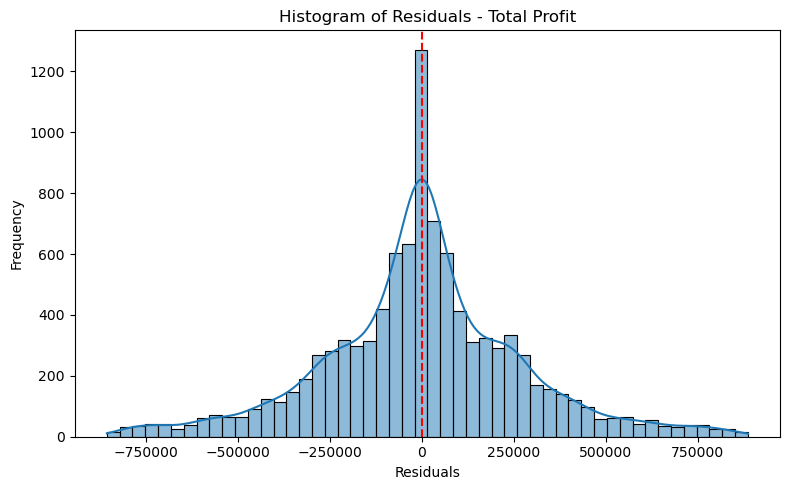

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

#Convert categorical variables into numeric dummy columns
df_model = pd.get_dummies(regression_df[['region', 'sales_channel', 'item_type', 'order_priority', 'season']], drop_first=True).astype(float)

#Fit the multiple linear regression model
y = regression_df['total_profit']
X = sm.add_constant(df_model)
model = sm.OLS(y, X).fit()

#Plot the residuals
plt.figure(figsize=(8, 5))
sns.histplot(model.resid, kde=True, bins=50)
plt.axvline(0, color='red', linestyle='--')
plt.title('Histogram of Residuals - Total Profit')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

The histogram displays a clear bell-shaped distribution centered around the zero mean, indicating that the residuals are normally distributed. The data fulfills this first assumption of a linear regression model.

Next, I will check whether the residuals exhibit homoscedasticity.

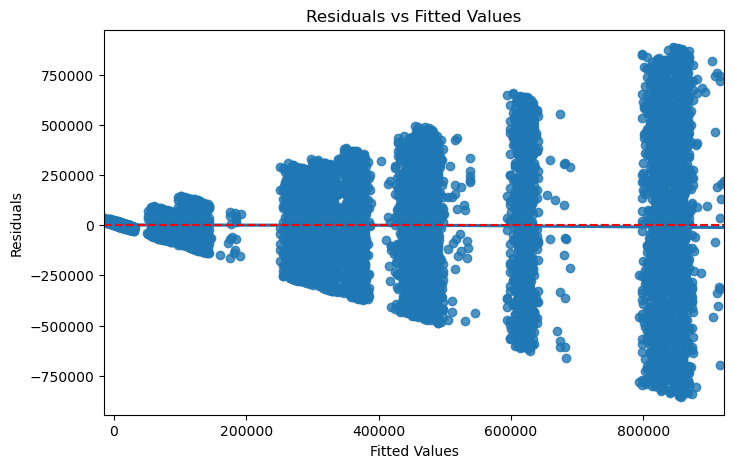

In [78]:
plt.figure(figsize=(8, 5))
sns.residplot(x=model.fittedvalues, y=model.resid, lowess=True)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

Here, an immediate issue becomes apparent. The plot demonstrates a distinct fan pattern, showing that the spread of residuals, the discrepancy between the model predictions and the actual profit, increases as the fitted values, the model predictions for each transaction, increase. When the model predicts low profit, the low fitted values, the errors are small, but when the model predicts high profit, the high fitted values, the errors become larger and further from the actual profit in both directions. This violates the assumption of homoscedasticity. 

A log transformation might resolve this issue, since it compresses the scale of the outcome variable by reducing the relative distance between large values while leaving small values comparatively unchanged. High total profit values will be pulled closer together on the log scale, which reduces the proportionally larger errors associated with high-profit predictions. This may result in a more uniform spread of the residuals across all fitted values, which would then satisfy the homoscedasticity assumption (Sigma Computing, 2026).

As such, I will try to correct for the spread of the residuals by applying a log transformation to total profit and re-generating the histogram and the residual plot to see if both assumptions can be met. 

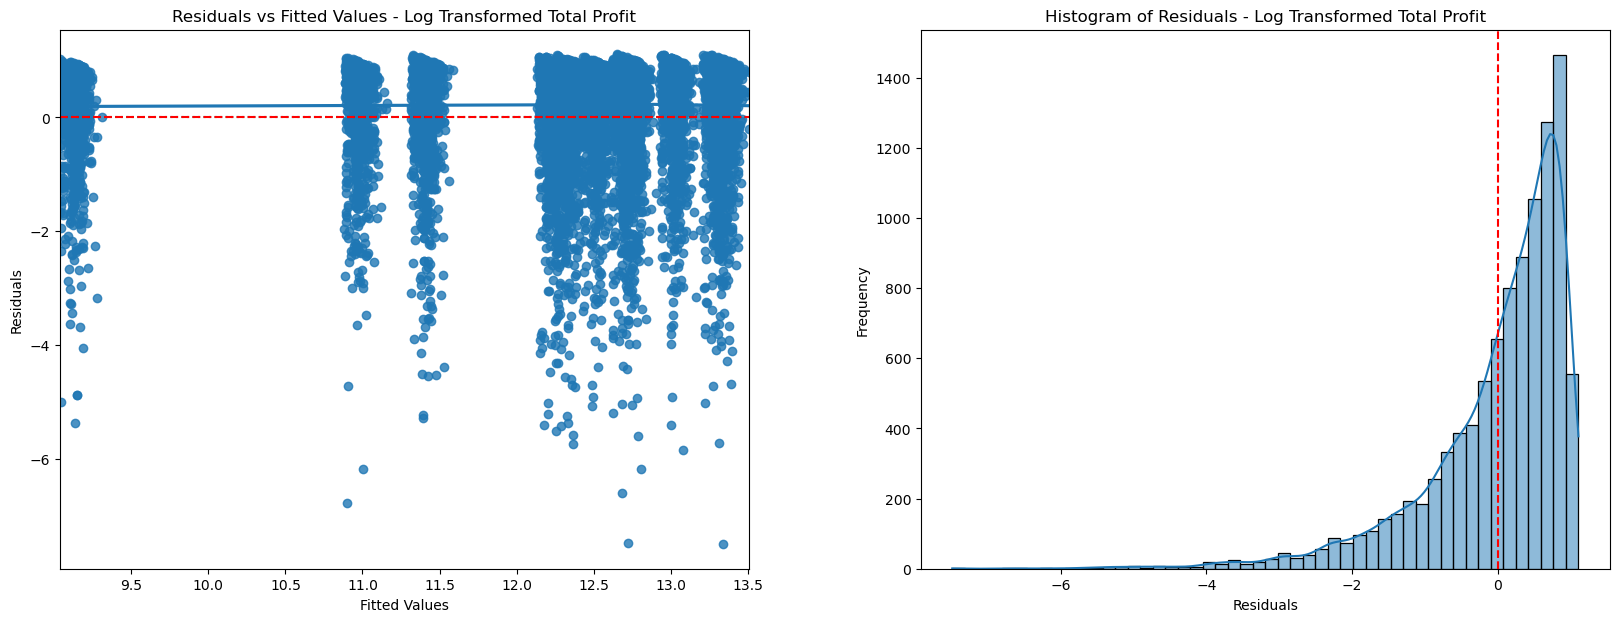

In [80]:
# Apply log transformation to total profit
regression_df['log_profit'] = np.log(regression_df['total_profit'])

# Refit the model with log transformed outcome
y_log = regression_df['log_profit']
model_log = sm.OLS(y_log, X).fit()

#Establish plot zone
fig1, ax=plt.subplots(1,2)
fig1.subplots_adjust(hspace=0.125, wspace=0.25)
fig1.set_size_inches(20,7)

# Residuals vs fitted values plot
sns.residplot(x=model_log.fittedvalues, y=model_log.resid, lowess=True, ax=ax[0])
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_xlabel('Fitted Values')
ax[0].set_ylabel('Residuals')
ax[0].set_title('Residuals vs Fitted Values - Log Transformed Total Profit')

# Residual histogram
sns.histplot(model_log.resid, kde=True, bins=50, ax=ax[1])
ax[1].axvline(0, color='red', linestyle='--')
ax[1].set_title('Histogram of Residuals - Log Transformed Total Profit')
ax[1].set_xlabel('Residuals')
ax[1].set_ylabel('Frequency')

plt.show()

The plots show that the log transformation improved homoscedasticity but introduced left skew in the residual distribution, trading one assumption violation for another.

This isn't terribly surprising, given that my model involves many categorical variables. Log transformations, just like other power transformations such as square root and Box-Cox, are designed to stabilize variance that scales continuously with the outcome variable, but are not well-equipped to handle  variance that jumps in discrete steps based on category membership. As such, further attempts to transform the data in this way will likely yield no better results, since the categorical nature of the predictors means that variance will never increase smoothly and continuously with the fitted values but will instead shift based on those categories.

I considered various other approaches to address the homoscedasticity violation. For instance, one of the first resolutions I considered was applying a heteroskedasticity-consistent (HC3) estimator, but this adjustment method is specifically recommended for sample sizes under 250 observations, and our dataset is far larger with 10,000 transactions (Kaufman, 2013, pp. 43-50).

Weighted least squares was also considered, as it resolves heteroscedasticity by applying different weights to data points to minimize the weighted sum of squared residuals and thus give less influence to data points with higher variance. However, this approach requires one to know the true variance structure in advance in order to find the appropriate weight size (Zilfimian, 2020). I also considered robust regression, which is specifically designed to handle situations where the OLS assumptions are violated, but it is usually used to address heteroskedasticity caused by outliers (Penn State Eberly College of Science, n.d.). In this case, the heteroskedasticity is structural, so robust regression is not indicated.

In the end, I was left with a choice between White’s HC0 estimator and quantile regression. HC0 is a basic heteroscedasticity-consistent estimator that does not specifically adjust for smaller sample sizes and is therefore more appropriate for our dataset than other estimators, such as HC3, which we already discussed (Baissa, 2024). Alternatively, I could choose quantile regression over linear regression entirely, selecting a model that is inherently built to handle problems such as those encountered in this dataset rather than making adjustments to a less purpose-fit model.

I ultimately selected quantile regression as the most appropriate technique for the analysis. Unlike ordinary least squares (OLS) regression, which estimates the mean of the dependent variable, quantile regression estimates the dependent variable’s conditional distribution. It is generally used when the response variable has a non-normal distribution, there are significant outliers in the data, and/or the data demonstrates heteroskedasticity ("Quantile regression: A flexible alternative to linear regression," n.d.). Quantile regression also provides a more nuanced answer to the research question than linear regression, since it offers insight into how the predictors affect total profit at different quantiles rather than just at the mean point. 

That said, quantile regression poses some notable disadvantages relative to OLS. OLS produces a single coefficient per predictor, which makes it much simpler to interpret than quantile regression, which produces a separate set of coefficients at each quantile. Additionally, when all the assumptions of OLS are satisfied, OLS is more statistically efficient, since the Gauss-Markov theorem guarantees it produces the smallest possible variance among all linear unbiased estimators. Quantile regression sacrifices some of that efficiency in exchange for robustness to heteroscedasticity and non-constant variance across the outcome distribution (Brenndoerfer, 2025).

In [83]:
#Define the regresion formula where total profit is outcome of region, item_type, sales_channel, order_priority, and season as predictive variables
formula = 'total_profit ~ C(region) + C(item_type) + C(sales_channel) + C(order_priority) + C(season)'

In [84]:
import warnings
import statsmodels.formula.api as smf

warnings.filterwarnings('ignore')

#Establish the quantiles at which the regression model will check the influential factor of the predictive variables
quantiles = [0.50, 0.75, 0.90, 0.95]
results = {}

#Fit the quantile regression model at each quantile and print the results
for q in quantiles:
    results[q] = smf.quantreg(formula, regression_df).fit(q=q)
    print(f"\n{'='*60}")
    print(f"Quantile Regression at q={q}")
    print(f"{'='*60}")
    print(f"Pseudo R²: {results[q].prsquared:.4f}")
    print(results[q].summary())


Quantile Regression at q=0.5
Pseudo R²: 0.3100
                         QuantReg Regression Results                          
Dep. Variable:           total_profit   Pseudo R-squared:               0.3100
Model:                       QuantReg   Bandwidth:                   4.763e+04
Method:                 Least Squares   Sparsity:                    3.341e+05
Date:                Wed, 29 Apr 2026   No. Observations:                10000
Time:                        08:38:52   Df Residuals:                     9975
                                        Df Model:                           24
                                                     coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
Intercept                                        4.69e+05   8233.730     56.962      0.000    4.53e+05    4.85e+05
C(region)[T.Australia and Oceania]             -4231.5

## E: Data Summary and Implications

The quantile regression model was fit at the 50th, 75th, 90th, and 95th percentiles. The model showed that item type was the strongest and most consistently statistically significant predictor, with p-values below 0.001 for almost all item types at every percentile, with the exception of cereal at the 50th percentile which had a p-value of 0.581. The results indicate that cosmetics and household goods consistently produced the largest positive coefficients, while fruits, personal care, and beverages produced the largest negative coefficients.

The only other variable of note was region, which, while largely non-significant, showed that North America was a significant driver of profit at the 75th percentile, with a p-value of 0.003 and a coefficient of 32,970 dollars, and, to a lesser extent, at the 90th percentile, with a p-value of 0.038 and a coefficient of 18,360 dollars. This suggests that North America produces more above-average transactions than other regions. However, this influence disappears at the 95th percentile. Overall, the results indicate that region has a marginal and inconsistent impact on total profit. The remaining predictors, sales channel, order priority, and seasonality, were non-significant at all four percentiles, suggesting that these factors do not meaningfully predict profit.

With this information, we can reject the null hypothesis that none of the factors predict profit per transaction at any quantile of the profit distribution, since we observed a clear influence across all item type categories and one region across two percentiles.

It should be recognized that this model is limited by the lack of continuous predictors. Units sold, unit price, and unit cost were excluded from the analysis, meaning the model cannot distinguish between the sales volumes or margin sizes as contributors to profit. As such, purely ascribing profit to item type may be misleading, as it may be the associated margin per unit or the number of units sold that is actually driving profit. Since total profit is a product of both these factors, this cannot be determined from the current model alone.

Based on these results, the recommended course of action for the business is to prioritize cosmetics and household goods as the primary drivers for increasing total profit, as these categories consistently produced the largest positive coefficients across all four percentiles. Additionally, since categories such as fruits, personal care, and beverages consistently produced the largest negative coefficients, those product types should be reassessed to determine whether there is a better way to improve profitability or whether they should be deprioritized within the business model.

In addition to this generalized recommended course of action, two directions for future study are proposed. First, a margin analysis, including unit price, unit cost, and units sold by item type, should be executed to determine how the household items and cosmetics categories are improving profit. If household goods and cosmetics cost substantially less to produce than they sell for on the market, and this is the primary driver of profit in those categories, then the business should focus on protecting and, if possible, expanding those margins. The business could also explore ways to reduce production costs and/or raise prices for other categories. Conversely, if demand volume is the driver, the business should focus on scaling supply and availability to maximize overall profit. 

Second, a time-series analysis using the original continuous order date variable to examine how total profit for household goods and cosmetics has varied over time would enable predictive analysis to determine how total profit for these categories might be expected to behave in the near future. This would reveal whether the profit advantages associated with high-performing item types such as cosmetics and household goods are stable over time or represent an emerging or declining trend, which would better inform how the business should act on the current findings.

## F: Source References

Adel, O. (2025, July 27). Sales records. Kaggle. 

https://www.kaggle.com/datasets/omaradel99/10000-sales-records?resource=download#


Baissa, D. K. (2024). Chapter 10: Robust standard errors: Tackling heteroscedasticity. In A basic introduction to stats concepts. bookdown.


Bobbitt, Z. (2021, November 16). The five assumptions of multiple linear regression. Statology. 

https://www.statology.org/multiple-linear-regression-assumptions/


Brenndoerfer, M. (2025, May 22). Gauss-Markov assumptions: Foundation of linear regression & OLS estimation. 

https://mbrenndoerfer.com/writing/gauss-markov-assumptions-linear-regression-ols-blue-estimator


Kaufman, R. L. (2013). Heteroskedasticity-consistent (Robust) standard errors. Heteroskedasticity in Regression: Detection and Correction, 43-50. 

https://doi.org/10.4135/9781452270128.n4


Penn State Eberly College of Science. (n.d.). T.1.1 - Robust Regression Methods [Website]. The Pennsylvania State University. 

https://online.stat.psu.edu/stat501/lesson/t/t.1/t.1.1-robust-regression-methods


Quantile regression: A flexible alternative to linear regression. (n.d.). Alfasoft. 

https://alfasoft.com/blog/products/statistics-and-data-analysis/quantile-regression-a-flexible-alternative-to-linear-regression/


Sigma Computing. (2026, April 24). What are homoscedasticity and heteroskedasticity in business analytics? 

https://www.sigmacomputing.com/blog/homoscedasticity-vs-heteroskedasticity


Zilfimian, L. (2020, February 16). Solving the problem of heteroscedasticity through weighted regression. Medium. 

https://medium.com/datamotus/solving-the-problem-of-heteroscedasticity-through-weighted-regression-e4a22f1afa6b
